In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import mglearn
import os
 
%matplotlib inline

In [5]:
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


# create a synthetic dataset
X, y = make_blobs(random_state=0)

# split data labels into a training and a test set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

logreg = LogisticRegression().fit(X_train, y_train)
print("Test score: ", logreg.score(X_test, y_test))

Test score:  0.88


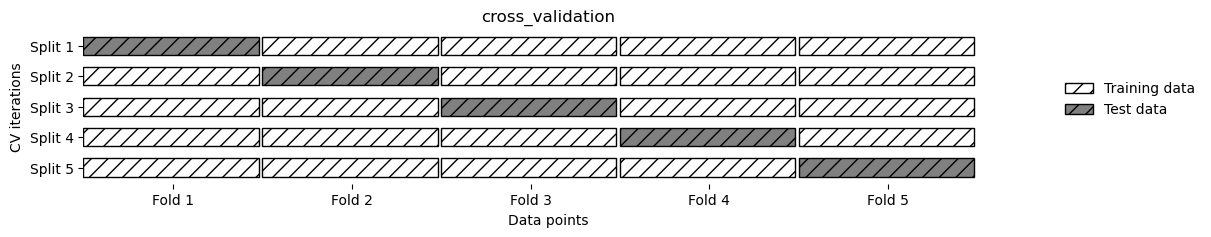

In [6]:
mglearn.plots.plot_cross_validation()

In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.datasets import load_iris

iris = load_iris()
logreg = LogisticRegression(max_iter=1_000)

scores = cross_val_score(logreg, iris.data, iris.target)
print(scores)

[0.96666667 1.         0.93333333 0.96666667 1.        ]


In [29]:
print(scores.mean())

0.9733333333333334


In [31]:
scores2 = cross_validate(logreg, iris.data, iris.target, return_train_score=True)
pd.DataFrame(scores2)

,fit_time,score_time,test_score,train_score
0,0.011823,0.000372,0.966667,0.966667
1,0.010634,0.000324,1.000000,0.966667
2,0.006606,0.000207,0.933333,0.983333
3,0.007906,0.000249,0.966667,0.983333
4,0.007196,0.000210,1.000000,0.975000


In [38]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=3)

print(cross_val_score(logreg, iris.data, iris.target, cv=kfold))

[0. 0. 0.]


In [39]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5)

print(cross_val_score(logreg, iris.data, iris.target, cv=kfold))

[1.         1.         0.86666667 0.93333333 0.83333333]


In [36]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [37]:
np.bincount(iris.target)

array([50, 50, 50])

In [44]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=3, shuffle=True, random_state=0)

print(cross_val_score(logreg, iris.data, iris.target, cv=kfold))

[0.98 0.96 0.96]


In [45]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()

scores = cross_val_score(logreg, iris.data, iris.target, cv=loo)
scores

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1.])

In [46]:
len(scores)

150

In [47]:
scores.mean()

np.float64(0.9666666666666667)

In [48]:
from sklearn.model_selection import ShuffleSplit

shuffle_split = ShuffleSplit(n_splits=10, train_size=.5, test_size=.5, random_state=0)
scores = cross_val_score(logreg, iris.data, iris.target, cv=shuffle_split)

In [49]:
print(scores)

[0.93333333 0.93333333 0.98666667 0.94666667 0.96       0.94666667 0.97333333
 1.         0.96       0.98666667]


In [51]:
from sklearn.model_selection import GroupKFold

X, y = make_blobs(n_samples=12, random_state=0)
groups = [0, 0, 0, 1, 1, 1, 1, 2, 2, 3, 3, 3]
scores = cross_val_score(logreg, X, y, groups=groups, cv=GroupKFold(n_splits=3))
print(scores)

[0.75       0.6        0.66666667]


In [53]:
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, random_state=0
)

print(X_train.shape, X_test.shape, sep='\n')


best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)

        score = svm.score(X_test, y_test)
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

print('Best score: ', best_score)
print('Best parameters: ', best_parameters)

(112, 4)
(38, 4)
Best score:  0.9736842105263158
Best parameters:  {'C': 100, 'gamma': 0.001}


In [55]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    iris.data, iris.target, random_state=0
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, random_state=1
)

best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)

        score = svm.score(X_valid, y_valid)
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)

score = svm.score(X_test, y_test)
print(score)
print(best_parameters)
print(best_score)

0.9210526315789473
{'C': 10, 'gamma': 0.001}
0.9642857142857143


In [57]:
best_score = 0
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        scores = cross_val_score(svm, X_trainval, y_trainval)
        score = scores.mean()

        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}

svm = SVC(**best_parameters)
svm.fit(X_trainval, y_trainval)
score = svm.score(X_test, y_test)
print(score)
print(best_score)
print(best_parameters)

0.9736842105263158
0.9731225296442687
{'C': 10, 'gamma': 0.1}


In [58]:
svm

,C,10
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False
